In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


c:\Users\allur\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "../data/processed/feature_engineered_ev_dataset.csv"
master_df = pd.read_csv(file_path)

In [3]:
features = ["ev_stock_lag1", "ev_stock_share_lag1", "charging_points_lag1"]
target = "ev_sales_share"

In [4]:
# CREATE SHAP MODELLING DATAFRAME
shap_df = master_df[
    ["country", "year", "ev_stock_lag1", "ev_stock_share_lag1", "charging_points_lag1", "ev_sales_share"]
].dropna().copy()

# Keep the same ordering used in the final XGBoost model
shap_df = shap_df.sort_values(["year", "country"]).reset_index(drop=True)

print("SHAP modelling dataset shape:")
print(shap_df.shape)
print("\nMissing values:")
print(shap_df.isnull().sum())
print("\nYears available:")
print(sorted(shap_df["year"].unique()))

SHAP modelling dataset shape:
(499, 6)

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [5]:
# CREATE TIME-BASED TRAIN / TEST SPLIT
shap_train_df = shap_df[shap_df["year"] <= 2022].copy()
shap_test_df = shap_df[shap_df["year"].isin([2023, 2024])].copy()

print("\nTraining dataset shape:")
print(shap_train_df.shape)
print("\nTesting dataset shape:")
print(shap_test_df.shape)


Training dataset shape:
(421, 6)

Testing dataset shape:
(78, 6)


In [6]:
# CREATE TRAINING AND TEST VARIABLES
X_train = shap_train_df[features]
y_train = shap_train_df[target]

X_test = shap_test_df[features]
y_test = shap_test_df[target]

print("\nX_train shape:")
print(X_train.shape)
print("\nX_test shape:")
print(X_test.shape)


X_train shape:
(421, 3)

X_test shape:
(78, 3)


In [7]:
# RECREATE FINAL TUNED XGBOOST MODEL
final_xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

# TRAIN FINAL XGBOOST MODEL
final_xgb_model.fit(X_train, y_train)

# VERIFY FINAL MODEL PERFORMANCE
y_pred = final_xgb_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred)
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nFinal XGBoost Performance Verification")
print(f"R²   : {final_r2:.4f}")
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")


Final XGBoost Performance Verification
R²   : 0.7491
MAE  : 7.4568
RMSE : 10.3212


In [8]:
# CREATE SHAP EXPLAINER
explainer = shap.TreeExplainer(final_xgb_model)

# CALCULATE SHAP VALUES FOR TEST DATA
shap_values = explainer(X_test)

print("\nSHAP values shape:")
print(shap_values.values.shape)
print("\nSHAP base value:")
print(shap_values.base_values[0])


SHAP values shape:
(78, 3)

SHAP base value:
4.9082146


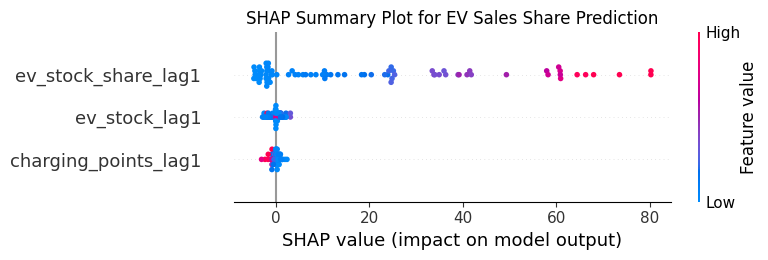

In [14]:
# SHAP SUMMARY BEESWARM PLOT
shap.summary_plot(shap_values.values, X_test, feature_names=features, show=False)
plt.title("SHAP Summary Plot for EV Sales Share Prediction")
plt.tight_layout()
plt.show()